# 01 - Data Exploration

Exploratory Data Analysis (EDA) for PRISM using Apache JIRA project data.

## Data Pipeline
1. **Raw data** (`data/raw/`): Issue-level JIRA exports — `issues.csv`, `changelog.csv`, `comments.csv`, `issuelinks.csv`
2. **Preprocessed data** (`data/processed/`): Project-level aggregates produced by `scripts/preprocess_jira_data.py`

## Objectives
- Inspect raw JIRA data structure and volume
- Explore the preprocessed project-level data
- Understand feature distributions and data quality
- Identify patterns and correlations relevant to risk prediction
- Analyze text fields available for LLM processing

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Show all columns without truncation, and full cell text up to 100 chars
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Raw Data Overview

The raw data comes from the [Apache JIRA Issues](https://www.kaggle.com/datasets/tedlozzo/apaches-jira-issues) Kaggle dataset.
We peek at each file to understand the schema before working with the preprocessed project-level data.

In [49]:
# Inspect each raw JIRA export for schema, file size, and sample column names.
# These four files are the sole inputs to scripts/preprocess_jira_data.py which
# aggregates them into the single project-level jira_projects.csv used by all
# downstream notebooks.
raw_files = {
    'issues.csv': 'Issue tracker records (bugs, features, improvements, tasks)',
    'changelog.csv': 'Issue field change history (status transitions, reassignments)',
    'comments.csv': 'Issue discussion comments (developer conversations)',
    'issuelinks.csv': 'Issue dependency links (blockers, clones, related)',
}

print('RAW DATA FILES')
print('=' * 70)
for fname, desc in raw_files.items():
    fpath = RAW_DIR / fname
    if fpath.exists():
        sample = pd.read_csv(fpath, nrows=5, low_memory=False)
        size_mb = fpath.stat().st_size / (1024 * 1024)
        print(f'\n{fname} ({size_mb:.0f} MB) — {desc}')
        print(f'  Columns ({len(sample.columns)}): {list(sample.columns)}')
    else:
        print(f'\n{fname} — NOT FOUND')

RAW DATA FILES

issues.csv (1818 MB) — Issue tracker records (bugs, features, improvements, tasks)
  Columns (37): ['id', 'key', 'summary', 'resolution.id', 'resolution.description', 'resolution.name', 'priority.id', 'priority.name', 'labels', 'assignee', 'status.id', 'status.description', 'status.name', 'statusCategory.id', 'statusCategory.key', 'statusCategory.colorName', 'statusCategory.name', 'customfield_12310921', 'creator', 'subtasks', 'reporter', 'votes.votes', 'issuetype.id', 'issuetype.description', 'issuetype.name', 'issuetype.subtask', 'project.id', 'project.key', 'project.name', 'projectCategory.id', 'projectCategory.description', 'projectCategory.name', 'resolutiondate', 'watches.watchCount', 'created', 'updated', 'description']

changelog.csv (2608 MB) — Issue field change history (status transitions, reassignments)
  Columns (11): ['id', 'key', 'id_1', 'author', 'created', 'field', 'fieldtype', 'from', 'fromString', 'to', 'toString']

comments.csv (3849 MB) — Issue disc

In [50]:
# Quick peek at issues schema
issues_sample = pd.read_csv(RAW_DIR / 'issues.csv', nrows=1000, low_memory=False)

print(f'Issues sample: {len(issues_sample)} rows, {len(issues_sample.columns)} columns')
print(f'\nProject keys in sample: {issues_sample["project.key"].nunique()}')
print(f'Issue types: {issues_sample["issuetype.name"].value_counts().to_dict()}')
print(f'Priorities: {issues_sample["priority.name"].value_counts().to_dict()}')
print(f'Statuses: {issues_sample["status.name"].value_counts().head(5).to_dict()}')
issues_sample.head()

Issues sample: 1000 rows, 37 columns

Project keys in sample: 45
Issue types: {'Bug': 732, 'Improvement': 159, 'New Feature': 62, 'Task': 24, 'Wish': 12, 'Test': 9, 'Sub-task': 2}
Priorities: {'Major': 634, 'Minor': 244, 'Critical': 42, 'Trivial': 31, 'Blocker': 19}
Statuses: {'Closed': 710, 'Resolved': 146, 'Open': 142, 'Reopened': 2}


,id,key,summary,resolution.id,resolution.description,resolution.name,priority.id,priority.name,labels,assignee,status.id,status.description,status.name,statusCategory.id,statusCategory.key,statusCategory.colorName,statusCategory.name,customfield_12310921,creator,subtasks,reporter,votes.votes,issuetype.id,issuetype.description,issuetype.name,issuetype.subtask,project.id,project.key,project.name,projectCategory.id,projectCategory.description,projectCategory.name,resolutiondate,watches.watchCount,created,updated,description
0,12451174,WW-712,Update config browser to work with the new syntax,1.0,A fix for this issue is checked into the tree and tested.,Fixed,4.0,Minor,[],632ec9dd,6,"The issue is considered finished, the resolution is correct. Issues which are not closed can be ...",Closed,3,done,green,Done,NaN,632ec9dd,[],632ec9dd,0,4,An improvement or enhancement to an existing feature or task.,Improvement,False,12311041,WW,Struts 2,10380.0,struts.apache.org,Struts Framework,2005-01-01 07:50:46,0,2005-01-01 07:47:50,2005-01-01 07:50:46,The config browser used Velocity calling the tags using the old syntax (single quoting literals)...
1,29159,XALANC-446,XALAN_C 1.9 or current do not build on Fedora core 3,1.0,A fix for this issue is checked into the tree and tested.,Fixed,1.0,Blocker,[],NaN,5,"A resolution has been taken, and it is awaiting verification by reporter. From here issues are e...",Resolved,3,done,green,Done,NaN,4fc0930d,[],4fc0930d,0,1,A problem which impairs or prevents the functions of the product.,Bug,False,10582,XALANC,XalanC,11460.0,Xalan Related Projects,Xalan,2004-12-30 05:30:36,1,2004-12-25 22:50:30,2005-01-01 10:20:52,Two types of errors:\n1- runConfigure and configure are not executable (I had to 'chmod -R a+x *...
2,12420130,ROL-587,"Problem with ADD new post, and DELETE post.",5.0,"All attempts at reproducing this issue failed, or not enough information was available to reprod...",Cannot Reproduce,2.0,Critical,[],4d4054ac,6,"The issue is considered finished, the resolution is correct. Issues which are not closed can be ...",Closed,3,done,green,Done,NaN,110153ae,[],110153ae,0,1,A problem which impairs or prevents the functions of the product.,Bug,False,12310906,ROL,Apache Roller,10331.0,NaN,Roller,2005-01-02 15:21:00,0,2005-01-01 13:52:46,2005-01-02 15:21:00,"When trying to add new post, I was getting next error page:\n\n500 Servlet Exception\n\njava.lan..."
3,29222,AXIS-1741,LogHandler can only work in GlobalConfiguration in client-config.wsdd,NaN,NaN,NaN,3.0,Major,[],NaN,1,The issue is open and ready for the assignee to start work on it.,Open,2,new,blue-gray,To Do,NaN,be1c6b12,[],be1c6b12,0,1,A problem which impairs or prevents the functions of the product.,Bug,False,10460,AXIS,Axis,10401.0,Axis and Axis2 related projects,Axis,NaN,0,2005-01-02 19:13:37,2005-01-02 19:35:36,org.apache.axis.handlers.LogHandler in requestFlow/responseFlow can only work within tag globalC...
4,29233,AXIS-1745,Decoding of service is broken in org.apache.axis.transport.http.SimpleAxisWorker.java,NaN,NaN,NaN,3.0,Major,[],NaN,1,The issue is open and ready for the assignee to start work on it.,Open,2,new,blue-gray,To Do,NaN,97843411,[],97843411,0,1,A problem which impairs or prevents the functions of the product.,Bug,False,10460,AXIS,Axis,10401.0,Axis and Axis2 related projects,Axis,NaN,1,2005-01-03 03:34:52,2005-01-03 03:34:52,"The following code assumes a lot of things:\n\n if (filePart.startsWith(""axis/serv..."


## 2. Load Preprocessed Project Data

The preprocessing script (`scripts/preprocess_jira_data.py`) aggregates issue-level data into
project-level metrics: team size, velocity, defect rate, resolution times, reopen rates, etc.
It also derives risk labels based on blocker ratio, reopen rate, and defect rate.

In [51]:
# Load the preprocessed project-level data
jira_path = PROCESSED_DIR / 'jira_projects.csv'
if not jira_path.exists():
    jira_path = PROCESSED_DIR / 'jira_projects_sample.csv'

df = pd.read_csv(jira_path)
print(f'Loaded {len(df)} projects with {len(df.columns)} columns from {jira_path.name}')
print(f'\nColumns: {df.columns.tolist()}')

Loaded 640 projects with 48 columns from jira_projects.csv

Columns: ['project_id', 'project_name', 'project_type', 'start_date', 'planned_end_date', 'actual_end_date', 'total_issues', 'open_issues', 'closed_issues', 'bug_count', 'feature_count', 'improvement_count', 'task_count', 'blocker_count', 'critical_count', 'blocker_ratio', 'critical_ratio', 'planned_hours', 'actual_hours', 'team_size', 'unique_assignees', 'unique_reporters', 'completion_rate', 'velocity', 'defect_rate', 'avg_resolution_days', 'median_resolution_days', 'reopen_count', 'reopen_rate', 'status_changes', 'churn_rate', 'project_duration_days', 'total_votes', 'total_watchers', 'avg_watchers_per_issue', 'status', 'priority', 'methodology', 'department', 'client_type', 'status_comments', 'project_description', 'team_feedback', 'complexity_score', 'dependencies', 'team_turnover', 'risk_score_composite', 'risk_level']


In [52]:
df.head()

,project_id,project_name,project_type,start_date,planned_end_date,actual_end_date,total_issues,open_issues,closed_issues,bug_count,feature_count,improvement_count,task_count,blocker_count,critical_count,blocker_ratio,critical_ratio,planned_hours,actual_hours,team_size,unique_assignees,unique_reporters,completion_rate,velocity,defect_rate,avg_resolution_days,median_resolution_days,reopen_count,reopen_rate,status_changes,churn_rate,project_duration_days,total_votes,total_watchers,avg_watchers_per_issue,status,priority,methodology,department,client_type,status_comments,project_description,team_feedback,complexity_score,dependencies,team_turnover,risk_score_composite,risk_level
0,ABDERA,Abdera,Development,2006-08-02,2017-01-30,NaN,311,51,260,215,14,67,2,9,10,0.028939,0.032154,2488,2284,157,9,154,83.60,1.81,0.6913,67.08,4.0,12,0.046154,316,1.016077,4302,19,85,0.273312,Active,Critical,Agile,Apache Foundation,External,That code works fine in trunk. If you have to use 0.3.0 version I'm sure that the next code also...,"Here are some of the outputs from running ""mvn test"" in rev. 452068\n\n-------------------------...",NaN,10,0,0.0,0.5952,High
1,ACCUMULO,Accumulo,Development,2011-10-03,2019-04-20,NaN,4746,138,4608,2252,140,1267,409,300,234,0.063211,0.049305,37968,37416,285,162,249,97.09,29.42,0.4745,439.96,18.0,426,0.092448,6404,1.349347,4699,254,12638,2.662874,Active,Critical,Agile,Apache Foundation,External,Is there a particular reason you went with the following pattern:\n{code}\nFile dfsDir = Files.c...,cloudtrace is a dependency for accumulo and it currently resides in the contrib folder. It shou...,NaN,10,0,0.0,0.6803,High
2,ACE,ACE,Development,2009-04-27,2018-02-15,NaN,539,47,492,194,42,172,76,8,14,0.014842,0.025974,4312,4124,78,15,77,91.28,4.55,0.3599,309.42,207.0,233,0.473577,1144,2.122449,3246,38,809,1.500928,Active,Critical,Agile,Apache Foundation,External,"on second thought, you could probably turn this around and have the server ""learn"" the polling i...","Apache Felix has seen quite a number of releases recently, so it's time to upgrade this codebase...",NaN,10,0,0.0,0.6001,High
3,ACL,ActiveCluster,Development,2004-10-24,2005-12-29,2005-12-30,5,0,5,1,1,1,1,0,0,0.000000,0.000000,40,40,4,1,3,100.00,0.35,0.2000,108.40,1.0,0,0.000000,5,1.000000,432,2,1,0.200000,Completed,Medium,Agile,Apache Foundation,External,"Sorry, didn't mean to file this under the wrong project....\n\nDone - added DestinationMarshalle...",The dependency guide needs to be updated for M4. It might be best to have a chart format which s...,NaN,1,0,0.0,0.1938,Low
4,ADDR,Addressing,Development,2004-08-20,2007-02-20,NaN,37,32,5,19,3,10,3,2,2,0.054054,0.054054,296,168,32,0,32,13.51,0.16,0.5135,0.00,0.0,0,0.000000,4,0.108108,963,2,7,0.189189,Active,Medium,Agile,Apache Foundation,External,"http://issues.apache.org/jira/browse/AXIS2-877\n\nwrong project :(\n\n-- dims\n\nSorry, incorrec...","Axis 1.2 implementation Java2WSDL handle SOAPAction in default is """" or any OPERATION name, howe...",NaN,9,0,0.0,0.4750,Medium


## 3. Data Overview

In [53]:
# High-level shape and dtype overview — confirms the CSV loaded correctly and
# highlights any unexpected object columns that should be numeric.
print('=' * 60)
print('DATA OVERVIEW')
print('=' * 60)
print(f'\nShape: {df.shape}')
print(f'\nColumn Types:')
print(df.dtypes)

DATA OVERVIEW

Shape: (640, 48)

Column Types:
project_id                 object
project_name               object
project_type               object
start_date                 object
planned_end_date           object
actual_end_date            object
total_issues                int64
open_issues                 int64
closed_issues               int64
bug_count                   int64
feature_count               int64
improvement_count           int64
task_count                  int64
blocker_count               int64
critical_count              int64
blocker_ratio             float64
critical_ratio            float64
planned_hours               int64
actual_hours                int64
team_size                   int64
unique_assignees            int64
unique_reporters            int64
completion_rate           float64
velocity                  float64
defect_rate               float64
avg_resolution_days       float64
median_resolution_days    float64
reopen_count                int64
r

In [54]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print('Missing Values:')
if len(missing_df) > 0:
    print(missing_df)
else:
    print('No missing values!')

print('\nNotes:')
print('  - team_feedback: 100% null — no equivalent field exists in JIRA data; excluded from analysis')
print('  - actual_end_date: null for Active projects (only Completed projects have a resolution date)')

# Drop team_feedback — it carries no signal
df = df.drop(columns=['team_feedback'], errors='ignore')

Missing Values:
                     Missing  Percentage
team_feedback            640      100.00
actual_end_date          606       94.69
status_comments            8        1.25
project_description        2        0.31

Notes:
  - team_feedback: 100% null — no equivalent field exists in JIRA data; excluded from analysis
  - actual_end_date: null for Active projects (only Completed projects have a resolution date)


## 4. Numerical Features Analysis

In [55]:
numerical_cols = [
    'total_issues', 'open_issues', 'closed_issues',
    'bug_count', 'feature_count', 'improvement_count', 'task_count',
    'blocker_count', 'critical_count', 'blocker_ratio', 'critical_ratio',
    'team_size', 'unique_assignees', 'unique_reporters',
    'completion_rate', 'velocity', 'defect_rate',
    'avg_resolution_days', 'median_resolution_days',
    'reopen_count', 'reopen_rate', 'status_changes', 'churn_rate',
    'project_duration_days',
    'total_votes', 'total_watchers', 'avg_watchers_per_issue',
    'complexity_score',
]
numerical_cols = [c for c in numerical_cols if c in df.columns]

stats = df[numerical_cols].describe().T
display(stats)

# Flag anomalies worth noting before modelling
print('\nData Quality Notes:')
print(f'  reopen_rate max = {df["reopen_rate"].max():.1f} — exceeds 1.0 for projects where reopens > closed issues')
print(f'    (e.g. a project with 1 closed issue reopened 17 times); cap to 1.0 before training')
print(f'  complexity_score 75th pct = {df["complexity_score"].quantile(0.75):.0f} (out of 10) — heavily right-saturated, low variance')

,count,mean,std,min,25%,50%,75%,max
total_issues,640.0,1767.537500,4450.519967,1.0,72.750000,342.500000,1292.250000,49833.000000
open_issues,640.0,269.525000,710.801192,0.0,10.000000,40.000000,165.250000,7018.000000
closed_issues,640.0,1475.551563,3811.487778,0.0,45.750000,272.000000,1044.750000,45156.000000
bug_count,640.0,885.737500,2306.183739,0.0,24.000000,145.000000,591.750000,30694.000000
feature_count,640.0,105.745312,249.468943,0.0,5.000000,26.500000,89.000000,2553.000000
improvement_count,640.0,438.320312,1187.894022,0.0,15.000000,85.500000,302.500000,14875.000000
task_count,640.0,115.592187,355.478202,0.0,4.000000,20.000000,77.000000,4497.000000
blocker_count,640.0,56.993750,211.052137,0.0,1.000000,5.000000,26.250000,2293.000000
critical_count,640.0,77.365625,315.827399,0.0,1.000000,8.000000,39.000000,5256.000000
blocker_ratio,640.0,0.023683,0.032662,0.0,0.003054,0.016308,0.031277,0.500000



Data Quality Notes:
  reopen_rate max = 17.0 — exceeds 1.0 for projects where reopens > closed issues
    (e.g. a project with 1 closed issue reopened 17 times); cap to 1.0 before training
  complexity_score 75th pct = 10 (out of 10) — heavily right-saturated, low variance


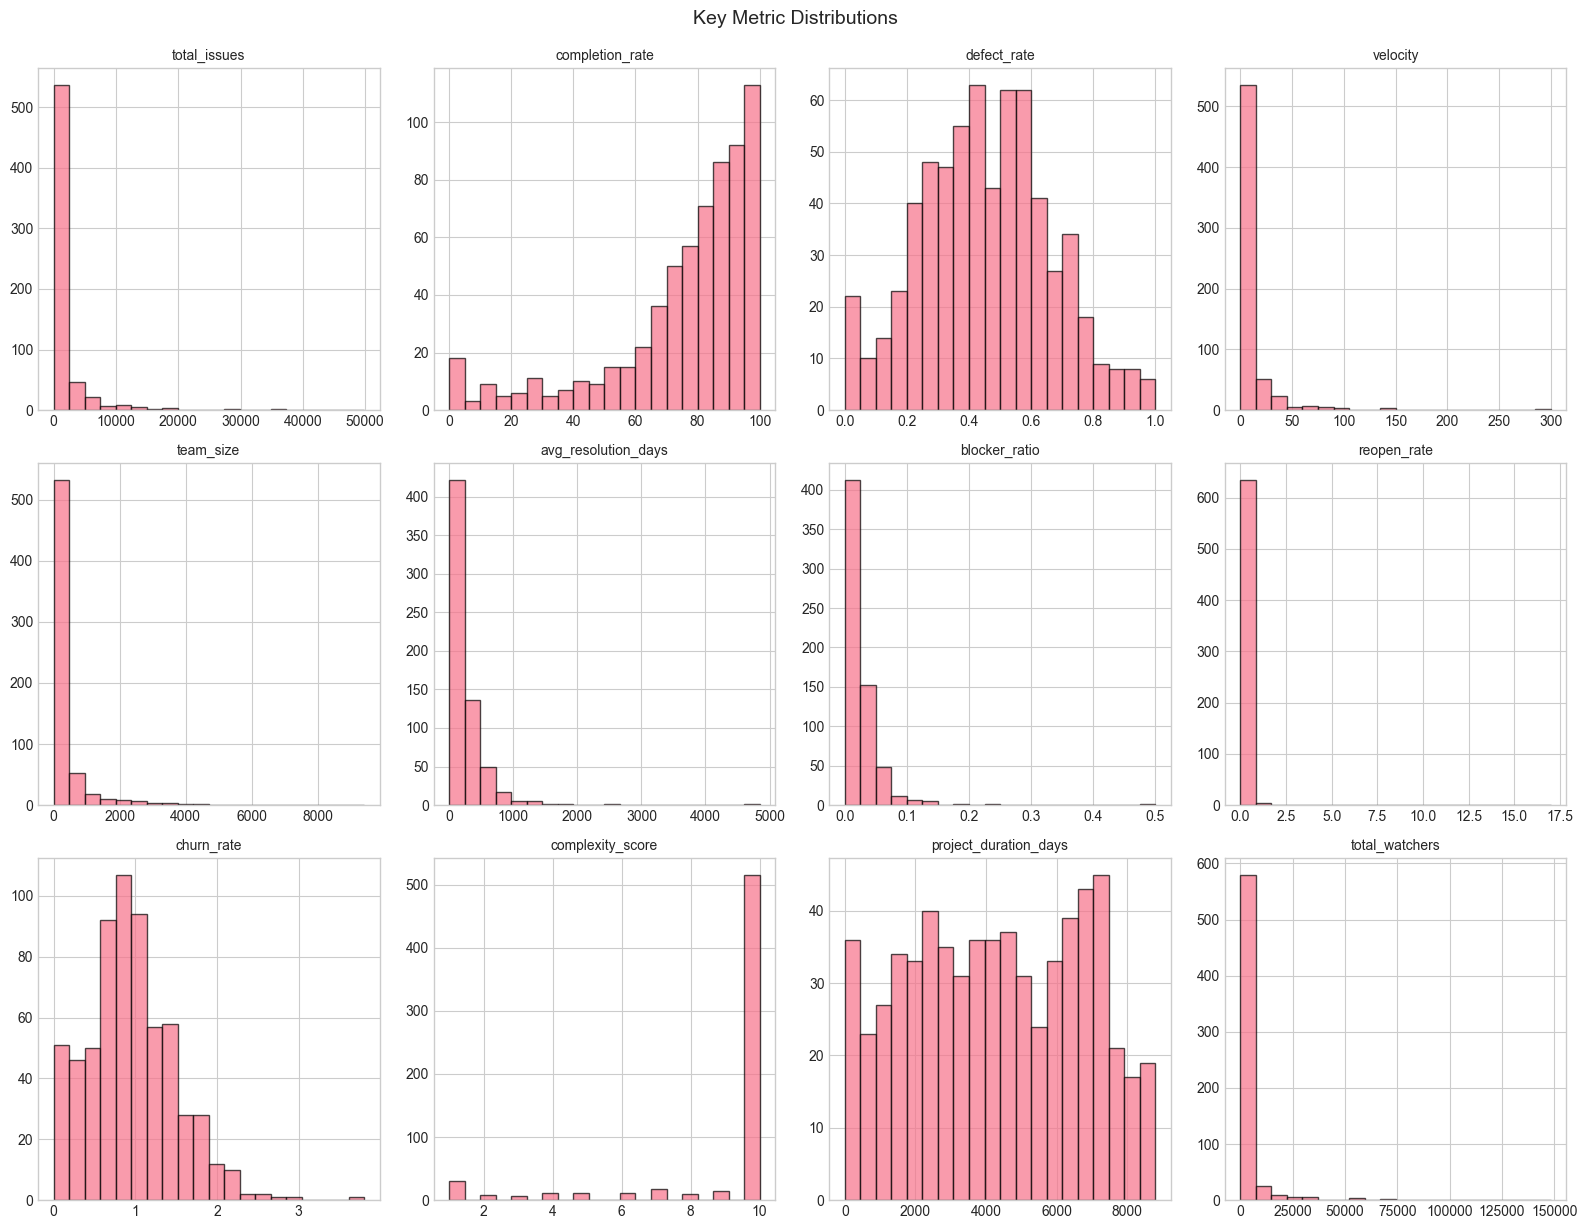

In [56]:
# Distribution plots for key metrics
plot_cols = [
    'total_issues', 'completion_rate', 'defect_rate', 'velocity',
    'team_size', 'avg_resolution_days', 'blocker_ratio', 'reopen_rate',
    'churn_rate', 'complexity_score', 'project_duration_days', 'total_watchers',
]
plot_cols = [c for c in plot_cols if c in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if i < len(axes):
        ax = axes[i]
        df[col].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('')

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Key Metric Distributions', y=1.02, fontsize=14)
plt.show()

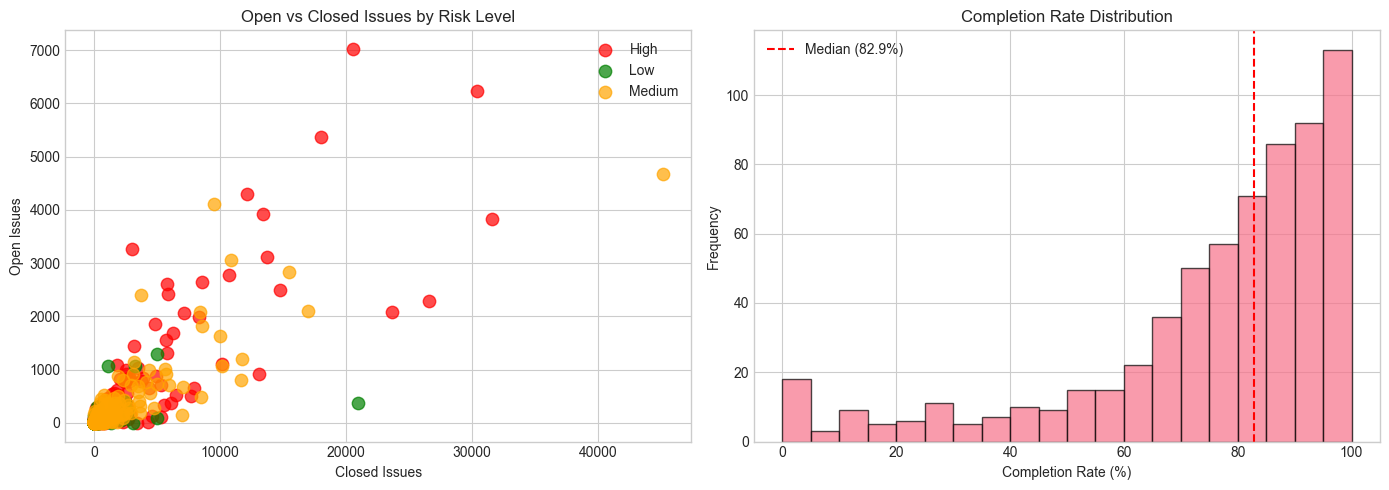

In [57]:
# Issue composition analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open vs Closed issues scatter
colors_map = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
for risk in df['risk_level'].unique():
    mask = df['risk_level'] == risk
    axes[0].scatter(df.loc[mask, 'closed_issues'], df.loc[mask, 'open_issues'],
                   label=risk, alpha=0.7, c=colors_map.get(risk, 'gray'), s=80)
axes[0].set_xlabel('Closed Issues')
axes[0].set_ylabel('Open Issues')
axes[0].set_title('Open vs Closed Issues by Risk Level')
axes[0].legend()

# Completion rate distribution
df['completion_rate'].hist(ax=axes[1], bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=df['completion_rate'].median(), color='red', linestyle='--', label=f'Median ({df["completion_rate"].median():.1f}%)')
axes[1].set_xlabel('Completion Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Completion Rate Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Categorical Features Analysis

In [58]:
categorical_cols = ['status', 'priority', 'risk_level', 'methodology',
                    'department', 'client_type', 'project_type']
categorical_cols = [c for c in categorical_cols if c in df.columns]

# Identify columns with zero variance (single unique value) — these carry no predictive signal
zero_variance_cols = [c for c in categorical_cols if df[c].nunique() == 1]
informative_cols = [c for c in categorical_cols if df[c].nunique() > 1]

if zero_variance_cols:
    print(f'⚠ Zero-variance columns (constant across all {len(df)} projects — exclude from ML):')
    for c in zero_variance_cols:
        print(f'  - {c}: "{df[c].iloc[0]}"')
    print()

for col in categorical_cols:
    print(f'\n{"=" * 40}')
    print(f'{col.upper()}')
    print(f'{"=" * 40}')
    print(df[col].value_counts())

⚠ Zero-variance columns (constant across all 640 projects — exclude from ML):
  - methodology: "Agile"
  - department: "Apache Foundation"
  - client_type: "External"
  - project_type: "Development"


STATUS
status
Active       604
Completed     36
Name: count, dtype: int64

PRIORITY
priority
Critical    310
Medium      308
High         22
Name: count, dtype: int64

RISK_LEVEL
risk_level
Medium    218
High      211
Low       211
Name: count, dtype: int64

METHODOLOGY
methodology
Agile    640
Name: count, dtype: int64

DEPARTMENT
department
Apache Foundation    640
Name: count, dtype: int64

CLIENT_TYPE
client_type
External    640
Name: count, dtype: int64

PROJECT_TYPE
project_type
Development    640
Name: count, dtype: int64


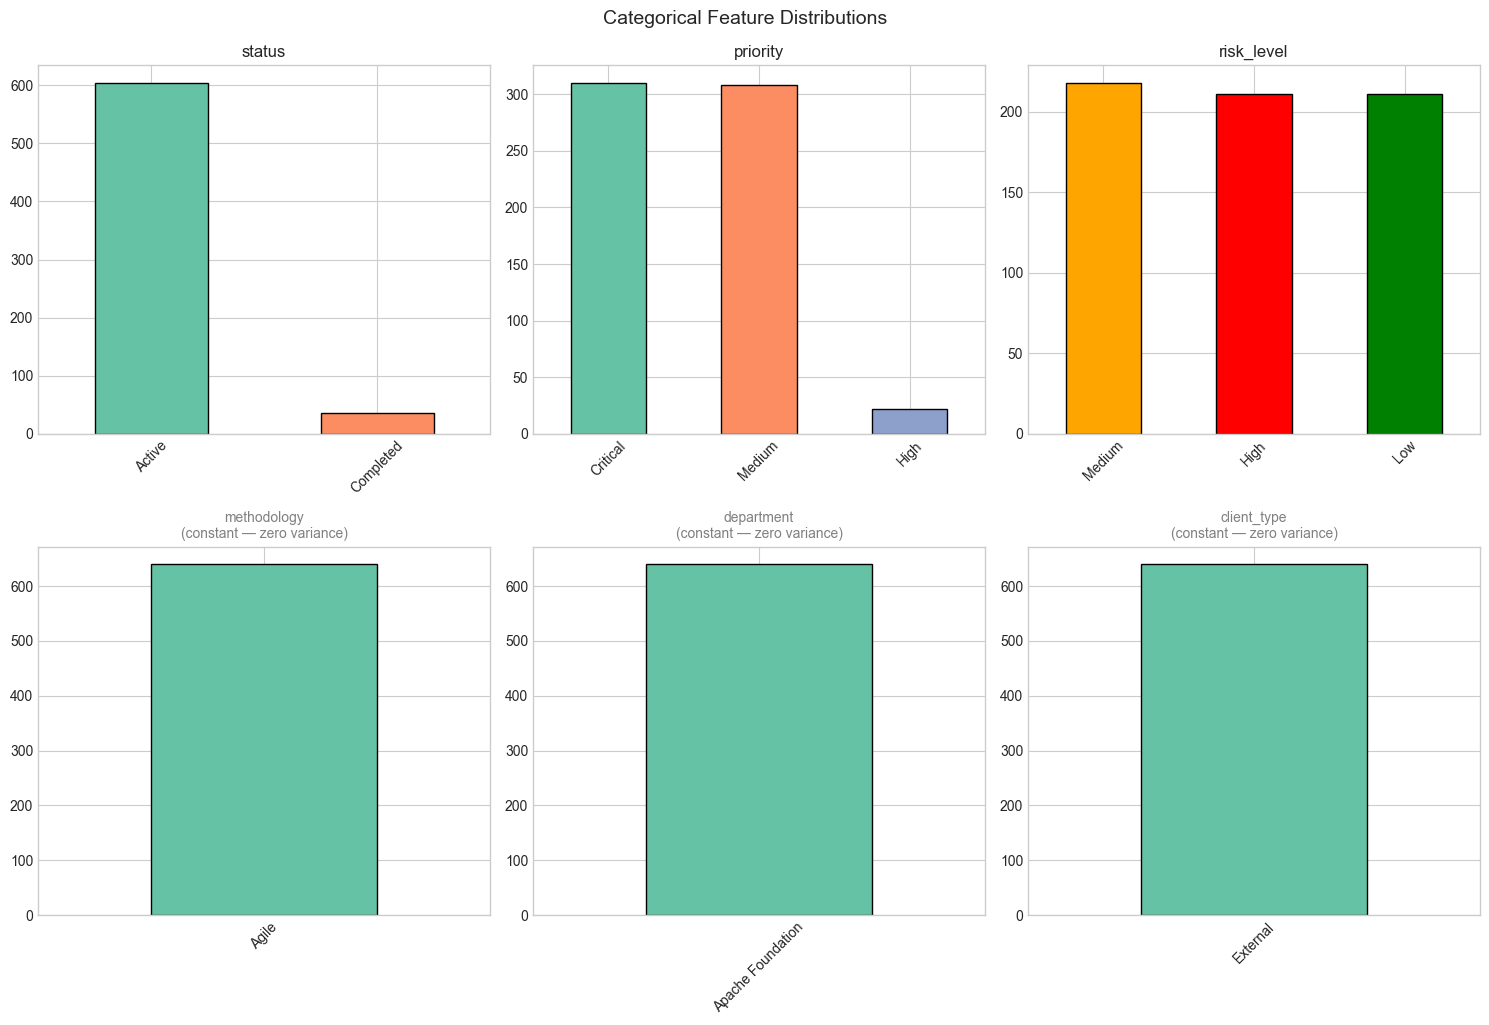

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:6]):
    ax = axes[i]
    counts = df[col].value_counts()

    if col == 'risk_level':
        color_map = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
        bar_colors = [color_map.get(x, 'gray') for x in counts.index]
    else:
        bar_colors = plt.cm.Set2(range(len(counts)))

    counts.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black')
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

    # Flag constant columns visually
    if col in zero_variance_cols:
        ax.set_title(f'{col}\n(constant — zero variance)', fontsize=10, color='gray')

for j in range(len(categorical_cols[:6]), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Categorical Feature Distributions', y=1.02, fontsize=14)
plt.show()

## 6. Risk Level Analysis (Target Variable)

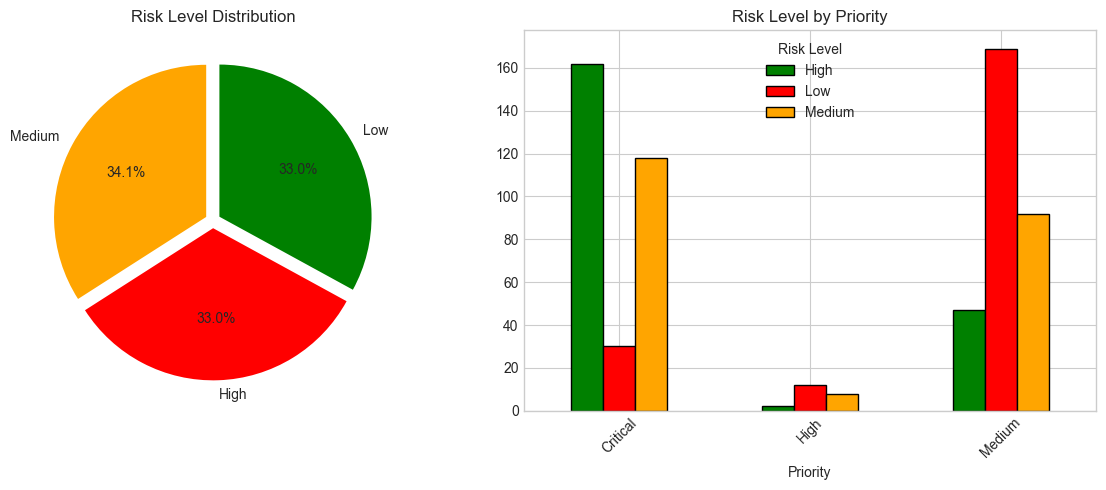

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
risk_counts = df['risk_level'].value_counts()
colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
pie_colors = [colors.get(r, 'gray') for r in risk_counts.index]
axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
           colors=pie_colors, startangle=90, explode=[0.05] * len(risk_counts))
axes[0].set_title('Risk Level Distribution')

# Risk by priority
if 'priority' in df.columns:
    cross_tab = pd.crosstab(df['priority'], df['risk_level'])
    cross_tab.plot(kind='bar', ax=axes[1], color=['green', 'red', 'orange'], edgecolor='black')
    axes[1].set_title('Risk Level by Priority')
    axes[1].set_xlabel('Priority')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Risk Level')

plt.tight_layout()
plt.show()

In [61]:
# Key metrics by risk level
risk_metrics = ['total_issues', 'completion_rate', 'defect_rate', 'velocity',
                'avg_resolution_days', 'blocker_ratio', 'reopen_rate', 'team_size',
                'churn_rate', 'complexity_score']
risk_metrics = [c for c in risk_metrics if c in df.columns]

risk_summary = df.groupby('risk_level')[risk_metrics].mean().round(3)
risk_summary

,total_issues,completion_rate,defect_rate,velocity,avg_resolution_days,blocker_ratio,reopen_rate,team_size,churn_rate,complexity_score
risk_level,,,,,,,,,,
High,2924.635,78.917,0.597,13.738,361.493,0.037,0.164,570.649,1.105,9.834
Low,467.735,68.988,0.301,5.646,171.937,0.012,0.014,68.640,0.753,7.493
Medium,1905.661,78.899,0.459,11.140,207.620,0.022,0.048,332.317,0.969,9.564


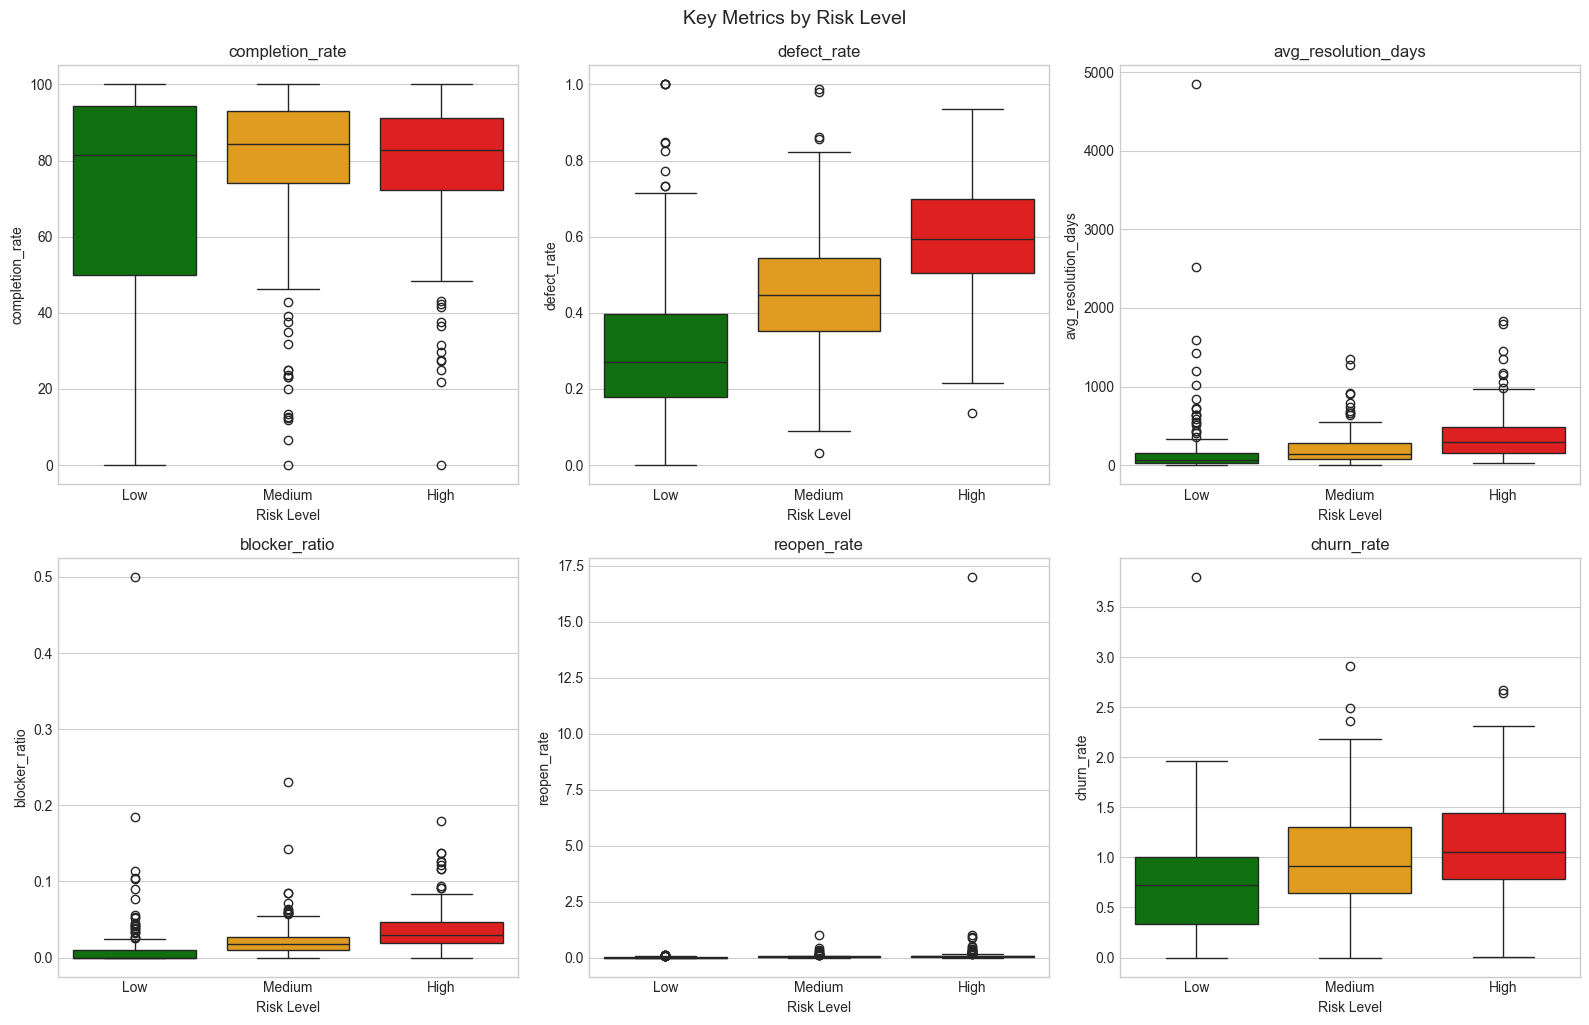

In [62]:
# Box plots by risk level for key metrics
key_metrics = ['completion_rate', 'defect_rate', 'avg_resolution_days',
               'blocker_ratio', 'reopen_rate', 'churn_rate']
key_metrics = [c for c in key_metrics if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_metrics):
    order = ['Low', 'Medium', 'High']
    order = [o for o in order if o in df['risk_level'].values]
    sns.boxplot(data=df, x='risk_level', y=col, ax=axes[i], order=order,
                hue='risk_level', legend=False,
                palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'})
    axes[i].set_title(col)
    axes[i].set_xlabel('Risk Level')

for j in range(len(key_metrics), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Key Metrics by Risk Level', y=1.02, fontsize=14)
plt.show()

## 7. Correlation Analysis

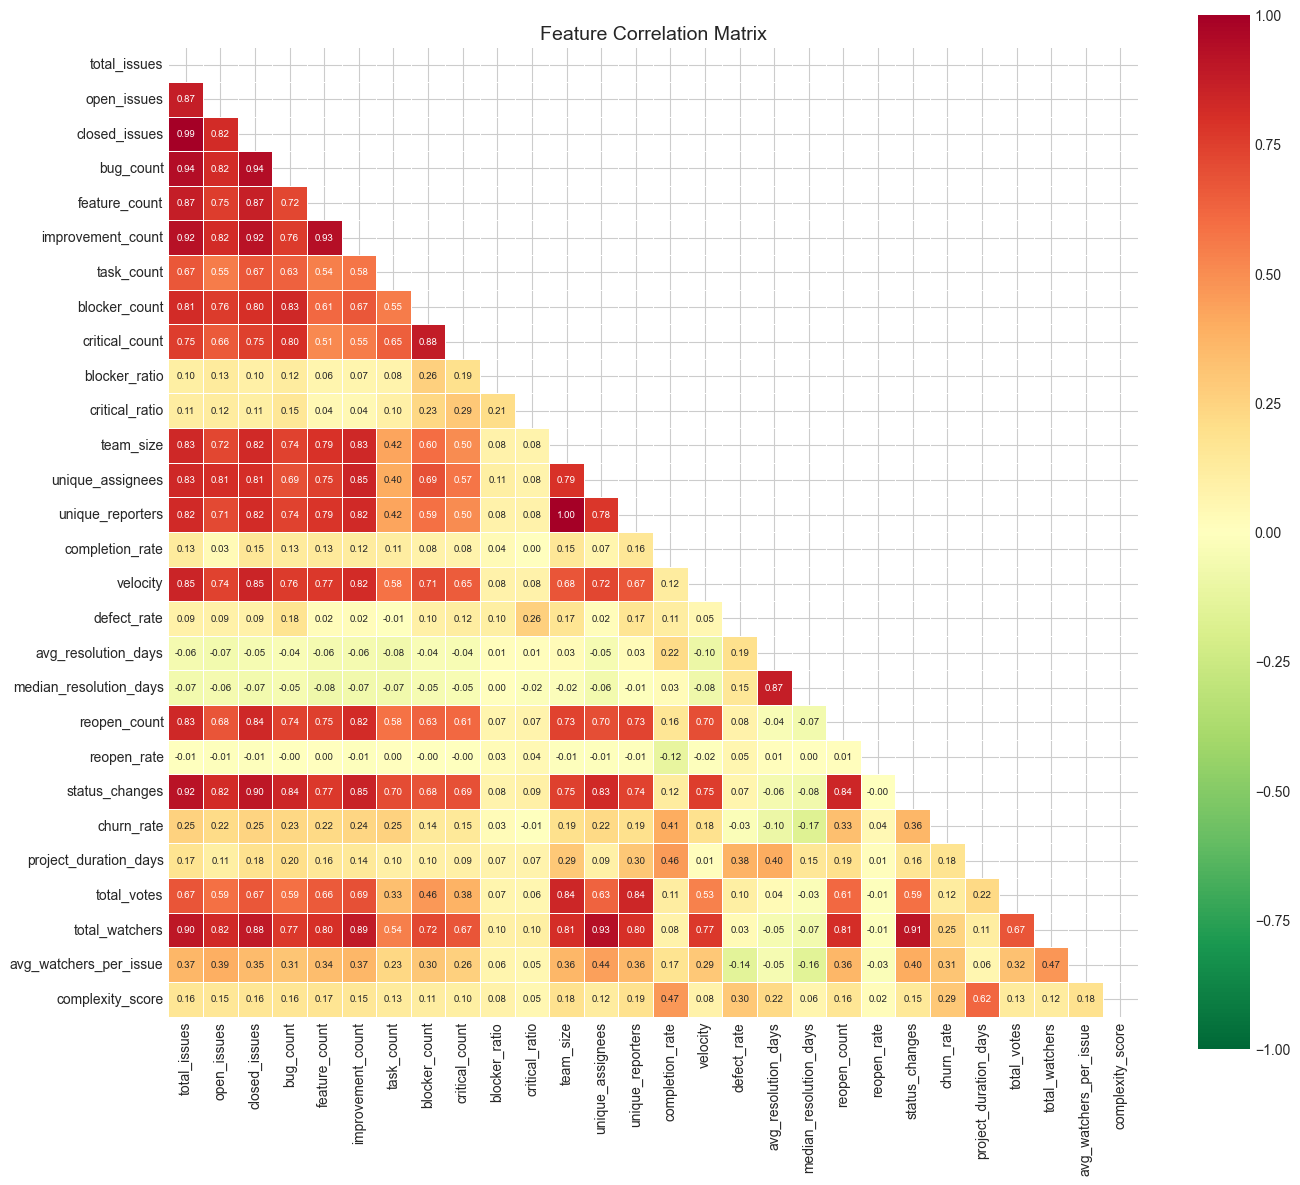

In [63]:
# Lower-triangle correlation heatmap (upper triangle masked to avoid redundancy).
# Red = strong positive correlation with another feature; green = strong negative.
# High inter-feature correlations (|r| > 0.7) signal multicollinearity — consider
# dropping one of the pair before ML training.
corr_cols = [c for c in numerical_cols if c in df.columns and df[c].notna().sum() > 0]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
           cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
           square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

Correlations with Risk Level:
defect_rate               0.571
project_duration_days     0.484
complexity_score          0.389
blocker_ratio             0.313
unique_reporters          0.285
team_size                 0.282
churn_rate                0.268
bug_count                 0.268
reopen_count              0.267
open_issues               0.251
blocker_count             0.245
avg_resolution_days       0.235
total_issues              0.224
total_votes               0.224
critical_ratio            0.224
status_changes            0.223
critical_count            0.221
closed_issues             0.214
total_watchers            0.193
unique_assignees          0.168
completion_rate           0.167
improvement_count         0.164
feature_count             0.152
velocity                  0.124
task_count                0.114
avg_watchers_per_issue    0.108
reopen_rate               0.091
median_resolution_days    0.089
Name: risk_numeric, dtype: float64


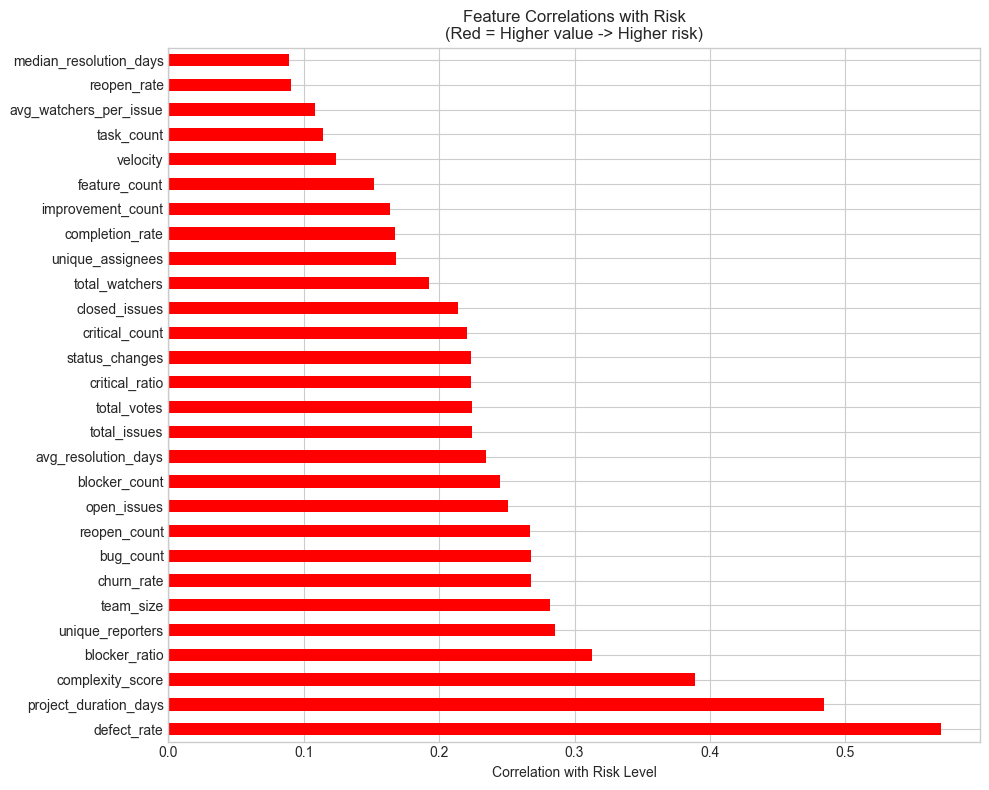


Note — Why all correlations are positive:
  This dataset consists entirely of Apache open-source projects (same methodology, department,
  and client type for every row). Project *size* is the dominant confounding variable.
  Larger, longer-running projects accumulate more issues, more bugs, more reopens, and longer
  resolution times — and also score higher on the composite risk metric because those absolute
  counts drive the percentile-based risk score upward.

  As a result, metrics that would normally be protective (e.g. high completion_rate) also
  correlate positively with risk here, because large Active projects both close many issues
  (high completion_rate) and have many open issues and slow resolution (high risk score).

  Practical implication: downstream models should use *rate* and *ratio* features
  (blocker_ratio, reopen_rate, defect_rate) rather than absolute counts (bug_count,
  reopen_count, total_issues) to avoid the size-confounding effect.



In [64]:
# Correlations with numeric risk level
df['risk_numeric'] = df['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

risk_corr = df[corr_cols + ['risk_numeric']].corr()['risk_numeric'].drop('risk_numeric').sort_values(ascending=False)

print('Correlations with Risk Level:')
print('=' * 40)
print(risk_corr.round(3))

# Bar plot
plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'green' for x in risk_corr]
risk_corr.plot(kind='barh', color=colors)
plt.xlabel('Correlation with Risk Level')
plt.title('Feature Correlations with Risk\n(Red = Higher value -> Higher risk)')
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

print("""
Note — Why all correlations are positive:
  This dataset consists entirely of Apache open-source projects (same methodology, department,
  and client type for every row). Project *size* is the dominant confounding variable.
  Larger, longer-running projects accumulate more issues, more bugs, more reopens, and longer
  resolution times — and also score higher on the composite risk metric because those absolute
  counts drive the percentile-based risk score upward.

  As a result, metrics that would normally be protective (e.g. high completion_rate) also
  correlate positively with risk here, because large Active projects both close many issues
  (high completion_rate) and have many open issues and slow resolution (high risk score).

  Practical implication: downstream models should use *rate* and *ratio* features
  (blocker_ratio, reopen_rate, defect_rate) rather than absolute counts (bug_count,
  reopen_count, total_issues) to avoid the size-confounding effect.
""")

## 8. Text Fields Analysis (for LLM)

In [65]:
# Measure raw text length per project — critical for LLM context-window budgeting.
# project_description is a concatenation of all issue descriptions; status_comments
# aggregates all issue comment threads. Both grow proportionally with project size.
text_cols = ['status_comments', 'project_description']
text_cols = [c for c in text_cols if c in df.columns]

for col in text_cols:
    lengths = df[col].fillna('').str.len()
    print(f'{col}:')
    print(f'  - Non-empty: {(lengths > 0).sum()}/{len(df)} projects')
    print(f'  - Mean length: {lengths.mean():.0f} chars')
    print(f'  - Min length:  {lengths.min():.0f} chars')
    print(f'  - Max length:  {lengths.max():.0f} chars')
    print()

print('⚠  LLM context-length warning:')
print('   project_description is a concatenation of all issue descriptions per project.')
print('   At up to ~1.3M characters for the largest projects, this exceeds all standard')
print('   LLM context windows (typically 4k–128k tokens).')
print('   Notebook 04 must chunk or summarise this text before passing it to a model.')

status_comments:
  - Non-empty: 632/640 projects
  - Mean length: 21744 chars
  - Min length:  0 chars
  - Max length:  784310 chars

project_description:
  - Non-empty: 638/640 projects
  - Mean length: 38128 chars
  - Min length:  0 chars
  - Max length:  1341675 chars

⚠  LLM context-length warning:
   project_description is a concatenation of all issue descriptions per project.
   At up to ~1.3M characters for the largest projects, this exceeds all standard
   LLM context windows (typically 4k–128k tokens).
   Notebook 04 must chunk or summarise this text before passing it to a model.


In [66]:
# Sample text by risk level
print('SAMPLE STATUS COMMENTS BY RISK LEVEL')
print('=' * 60)

for risk in ['High', 'Medium', 'Low']:
    subset = df[df['risk_level'] == risk]
    if len(subset) > 0:
        sample = subset['status_comments'].dropna().iloc[0] if len(subset['status_comments'].dropna()) > 0 else 'N/A'
        print(f'\n[{risk} Risk] ({len(subset)} projects):')
        print(f'{str(sample)[:400]}...' if len(str(sample)) > 400 else sample)

SAMPLE STATUS COMMENTS BY RISK LEVEL

[High Risk] (211 projects):
That code works fine in trunk. If you have to use 0.3.0 version I'm sure that the next code also works fine in that version:

IntegerElement items = feed.addExtension(OpenSearchExtensionFactory.ITEMS_PER_PAGE );
items.setText(itemsPerPage);
IntegerElement total = feed.addExtension(OpenSearchExtensionFactory.TOTAL_RESULTS );
total.setText(totalResults);
IntegerElement start = feed.addExtension(Open...

[Medium Risk] (218 projects):
http://issues.apache.org/jira/browse/AXIS2-877

wrong project :(

-- dims

Sorry, incorrect project was set. Please, close this issue.

With this patch it's possible to pass an empty string as action uri. Simply added some empty String checks.

It's a little more complex than that if you want the handlers to be able to process empty action without faulting.
This is the patch set I'm using at the m...

[Low Risk] (211 projects):
Sorry, didn't mean to file this under the wrong project....

Done -

In [67]:
# Word frequency by risk tier — reveals vocabulary signals that can inform LLM
# prompt design (e.g. words like "blocker", "delayed", "failed" in High-risk
# projects vs "fixed", "released", "improved" in Low-risk projects).
from collections import Counter
import re

def get_word_freq(text_series, min_length=4):
    all_text = ' '.join(text_series.fillna('').str.lower())
    words = re.findall(r'\b[a-z]+\b', all_text)
    words = [w for w in words if len(w) >= min_length]
    return Counter(words)

high_risk_words = get_word_freq(df[df['risk_level'] == 'High']['status_comments'])
low_risk_words = get_word_freq(df[df['risk_level'] == 'Low']['status_comments'])

print('Top 15 Words in HIGH-Risk Projects:')
print(high_risk_words.most_common(15))

print('\nTop 15 Words in LOW-Risk Projects:')
print(low_risk_words.most_common(15))

Top 15 Words in HIGH-Risk Projects:
[('apache', 8162), ('java', 7104), ('this', 7056), ('that', 4762), ('with', 3694), ('color', 3257), ('https', 2663), ('patch', 2653), ('info', 2363), ('test', 2337), ('from', 2236), ('server', 2200), ('have', 2166), ('maven', 1974), ('local', 1812)]

Top 15 Words in LOW-Risk Projects:
[('apache', 9932), ('java', 5853), ('this', 5496), ('https', 3576), ('github', 3304), ('pull', 3231), ('that', 2848), ('test', 2667), ('with', 2591), ('import', 2453), ('maven', 2349), ('name', 2341), ('main', 2323), ('license', 2254), ('color', 2156)]


## 9. Data Quality Summary

In [68]:
print('=' * 60)
print('DATA QUALITY SUMMARY')
print('=' * 60)

# Use the original schema column count, not df.columns which accumulates side-effect columns
schema_cols = [c for c in df.columns if c not in ('risk_numeric',)]
print(f'\nTotal projects: {len(df)}')
print(f'Total schema features: {len(schema_cols)} (excl. derived analysis columns)')
print(f'Missing values: {df[schema_cols].isnull().sum().sum()} ({(df[schema_cols].isnull().sum().sum() / (len(df) * len(schema_cols)) * 100):.2f}%)')

print(f'\nRisk Distribution:')
for risk, count in df['risk_level'].value_counts().items():
    pct = count / len(df) * 100
    print(f'   - {risk}: {count} ({pct:.1f}%)')

print(f'\nProject Scale (total issues per project):')
print(f'   - Min: {df["total_issues"].min()}')
print(f'   - Median: {df["total_issues"].median():.0f}')
print(f'   - Max: {df["total_issues"].max()}')
print(f'   - Total issues across all projects: {df["total_issues"].sum():,}')

print(f'\nText Data Available:')
for col in text_cols:
    non_empty = (df[col].fillna('').str.len() > 0).sum()
    print(f'   - {col}: {non_empty}/{len(df)} projects')

print(f'\nKey Risk Indicators (mean by risk level):')
risk_indicators = ['defect_rate', 'blocker_ratio', 'reopen_rate', 'avg_resolution_days']
risk_indicators = [c for c in risk_indicators if c in df.columns]
print(df.groupby('risk_level')[risk_indicators].mean().round(4))

print(f'\nML Readiness Flags:')
print(f'   - team_feedback: dropped (100% null, no JIRA source)')
print(f'   - Zero-variance cols to exclude: {zero_variance_cols}')
print(f'   - reopen_rate: cap to 1.0 before training (current max = {df["reopen_rate"].max():.1f})')

DATA QUALITY SUMMARY

Total projects: 640
Total schema features: 47 (excl. derived analysis columns)
Missing values: 616 (2.05%)

Risk Distribution:
   - Medium: 218 (34.1%)
   - High: 211 (33.0%)
   - Low: 211 (33.0%)

Project Scale (total issues per project):
   - Min: 1
   - Median: 342
   - Max: 49833
   - Total issues across all projects: 1,131,224

Text Data Available:
   - status_comments: 632/640 projects
   - project_description: 638/640 projects

Key Risk Indicators (mean by risk level):
            defect_rate  blocker_ratio  reopen_rate  avg_resolution_days
risk_level                                                              
High             0.5968         0.0372       0.1645             361.4930
Low              0.3014         0.0121       0.0137             171.9370
Medium           0.4595         0.0218       0.0478             207.6203

ML Readiness Flags:
   - team_feedback: dropped (100% null, no JIRA source)
   - Zero-variance cols to exclude: ['methodology', 'de

## 10. Key Insights

### Data Source
- Real Apache JIRA data preprocessed into project-level aggregates
- Each row represents one Apache project with metrics derived from its issues, comments, and changelog

### Risk Indicators
- **Defect rate**, **blocker ratio**, **reopen rate**, and **avg resolution time** show clear separation across risk levels
- Risk labels are balanced: ~33% High / 33% Medium / 33% Low (percentile-based composite score)

### ML Features
- Strong rate/ratio features: `defect_rate`, `blocker_ratio`, `reopen_rate`, `churn_rate`, `avg_resolution_days`
- Team metrics: `team_size`, `unique_assignees`, `velocity`
- Engagement signals: `total_votes`, `total_watchers`
- **Exclude** constant-value columns (`methodology`, `department`, `client_type`, `project_type`) — zero variance
- **Cap** `reopen_rate` at 1.0 before training (outliers from projects with very few closed issues)

### Correlation Caveat — All Correlations Are Positive
Since all 640 rows are Apache open-source projects with the same methodology and department,
**project size** is a strong confounding variable. Larger projects accumulate more issues,
more bugs, and more status changes — which drives both their absolute metrics and their
percentile-based risk score upward. This causes even "protective" metrics like
`completion_rate` to correlate positively with risk.

Prefer **rate and ratio features** (e.g. `blocker_ratio`, `defect_rate`) over raw counts
(e.g. `bug_count`, `reopen_count`) in downstream models to reduce size confounding.

### Text Data for LLM
- `status_comments`: aggregated JIRA comments per project
- `project_description`: aggregated issue descriptions per project
- **⚠ Context-length warning**: `project_description` can reach ~1.3M characters for large projects — notebook 04 must chunk or truncate before passing to any LLM

### Missing / Placeholder Fields
- `team_feedback`: dropped — 100% null with no JIRA source equivalent
- `actual_end_date`: null for Active projects (94.7% of dataset); only Completed projects have a resolution date

### Next Steps
1. Feature engineering — apply rate/ratio features, cap `reopen_rate`, drop zero-variance columns (see `02_feature_engineering.ipynb`)
2. ML model training (see `03_ml_modeling.ipynb`)
3. LLM analysis of text fields with chunking strategy (see `04_llm_experiments.ipynb`)